In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
cats = np.array(["apple", "banana", "orange"])
print(cats.dtype)
values = np.array([5, 7, 3])

<U6


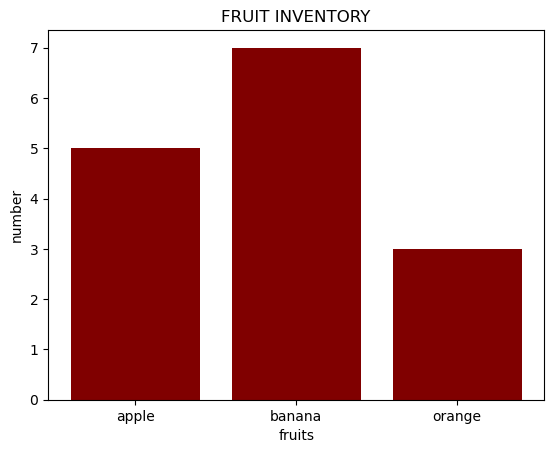

In [41]:
plt.bar(cats, values, color = "maroon", width = 0.8)
plt.xlabel("fruits")
plt.ylabel("number")
plt.title("fruit inventory".upper())
plt.show()

In [42]:
# using pandas 
fruit_data = pd.DataFrame({"fruit": cats, "number": values})
fruit_data.head()

,fruit,number
0,apple,5
1,banana,7
2,orange,3


<Axes: xlabel='fruit'>

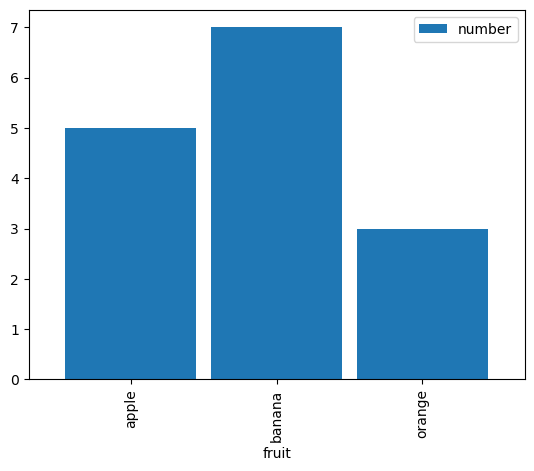

In [43]:
fruit_data.plot.bar(x = "fruit", y = "number", width = 0.9)

# lambda

In [44]:
lamb = lambda x: x**2
mylist = [1,2,3,4]
new_list = map(lamb, mylist)
list(new_list)

[1, 4, 9, 16]

# Bisection Method

In [45]:
#f = lambda x: (-2*np.pi*x**2) + 2*x +5

f = lambda x: -x**3 - 2*x**2 +3*x + 2

In [46]:
max_error = 0.001
error = 1
interval = {"left": -1, "right": 1}
midpoint = None
#while error > max_error:
for i in range(50): #start with 10 interations
    #print(f"iteration {i}")
    left = f(interval["left"])
    right = f(interval["right"])
    # check if either one of intervals is right answer
    # check if signs of both sides 
    #print(left,right)
    if (left < 0 and right > 0) or (left > 0 and right < 0): # this should be assumed
        midpoint = (interval["left"] + interval["right"]) / 2
        midpoint_value = f(midpoint)
        #print(f"midpoint is {midpoint}")
        if midpoint_value == 0:
            break
        elif midpoint_value > 0 and right < 0 or midpoint_value < 0 and right > 0:
            interval["left"] = midpoint
        elif midpoint_value > 0 and left < 0 or midpoint_value < 0 and left > 0:
            interval["right"] = midpoint

    #print(f"interval is now {interval}\n\n")


print(f"approximent root is {midpoint}")
    

approximent root is -0.5293165801288406


In [47]:
print(f(-0.7469935057673762))

-0.9401572610456412


# Secant Method

In [48]:
f = lambda x: x**2 - 2

In [49]:
#x0 = 2; x1 = 2.5 # guesses

In [50]:
#x0 = 2; x1 = 2.5 # guesses

def get_root(f, x0, x1, max_error):
    error = 1
    guess = lambda x0, x1: x1 - f(x1)*((x1 - x0)/(f(x1) - f(x0)))
    iterations = 0
    while error >= max_error:
        iterations += 1
        new_guess = guess(x0, x1)
        error  = abs((new_guess - x1) / new_guess) * 100
        x0 = x1
        x1 = new_guess
    print(f"finished in {iterations} iterations")
    return new_guess
        
root = get_root(f, 2, 2.5, 0.001)
print(f"Your root approximation is: {round(root, 5)}")

finished in 6 iterations
Your root approximation is: 1.41421


In [51]:
f2 = lambda x: x**3 - x**2 - 2
root = get_root(f2, 6, 10, 0.01)
print(f"Your root approximation is: {round(root, 5)}")

finished in 11 iterations
Your root approximation is: 1.69562


In [54]:
f3 = lambda x: np.sin(x)
root = get_root(f3, 11, 13, 1e-5)
print(f"Your root approximation is: {round(root, 5)}")

finished in 5 iterations
Your root approximation is: 12.56637


# Lab 12 - Numerical Methods

In [53]:
a = np.linspace(-10, 10, 100, endpoint = False)
print(a)

[-10.   -9.8  -9.6  -9.4  -9.2  -9.   -8.8  -8.6  -8.4  -8.2  -8.   -7.8
  -7.6  -7.4  -7.2  -7.   -6.8  -6.6  -6.4  -6.2  -6.   -5.8  -5.6  -5.4
  -5.2  -5.   -4.8  -4.6  -4.4  -4.2  -4.   -3.8  -3.6  -3.4  -3.2  -3.
  -2.8  -2.6  -2.4  -2.2  -2.   -1.8  -1.6  -1.4  -1.2  -1.   -0.8  -0.6
  -0.4  -0.2   0.    0.2   0.4   0.6   0.8   1.    1.2   1.4   1.6   1.8
   2.    2.2   2.4   2.6   2.8   3.    3.2   3.4   3.6   3.8   4.    4.2
   4.4   4.6   4.8   5.    5.2   5.4   5.6   5.8   6.    6.2   6.4   6.6
   6.8   7.    7.2   7.4   7.6   7.8   8.    8.2   8.4   8.6   8.8   9.
   9.2   9.4   9.6   9.8]


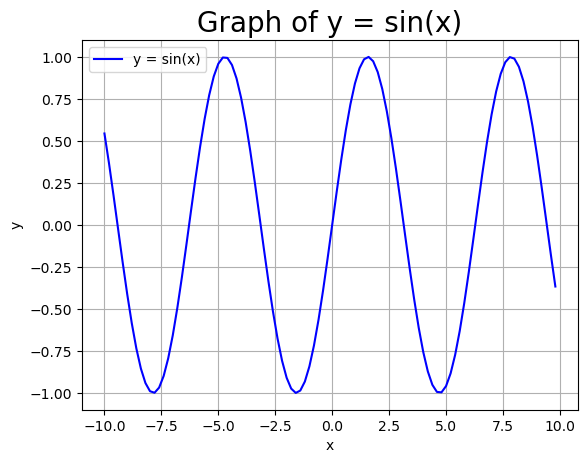

In [46]:
x = np.linspace(-10, 10, 100, endpoint = False)
func = lambda x: np.sin(x)
y = func(x)

plt.plot(x, y, label = "y = sin(x)", color = "blue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Graph of y = sin(x)", fontsize = 20)
plt.legend()
plt.grid()
plt.show()

# Numerical Integration

In [9]:
f = lambda x: x*3 - 3*x + 5
interval = [0,2]
dx = 0.1
n = int((interval[1] - interval[0]) / dx)
print(n)
x = np.linspace(interval[0], interval[1], n, endpoint = False)

20


In [45]:
def integrate (f, a, b, dx = 0.1):
    n = int((b - a) / dx)
    x = np.linspace(a, b, n, endpoint = False)
    y = f(x)
    area = 0

    for i in x:
        sub_area = (dx / 2) * (f(i) + f(i +dx))
        area += sub_area
    
    return area
    

In [57]:
f = lambda x: x**3 - 3*x + 5

area = integrate(f, 0, 100, 0.00001)
print(f"the area of this function is {area}")

the area of this function is 24985500.000000153


In [56]:
print(((24985500 - area) / 24985500) * 100)

-6.113021642029917e-13


# figure() and subplot()

In [80]:
x = np.linspace(-5, 5, 51)
y_sin = np.sin(x)
y_cos = np.cos(x)

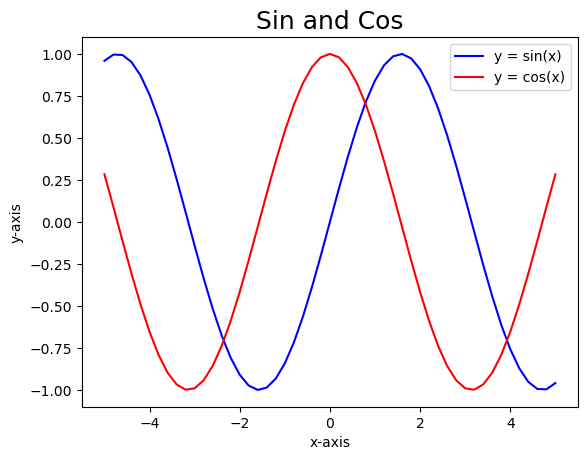

In [81]:
plt.plot(x, y_sin, color = "blue", label = "y = sin(x)")
plt.plot(x, y_cos, color = "red", label = "y = cos(x)")

plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.title("Sin and Cos", fontsize = 18)
plt.legend()
plt.show()

#### two plots

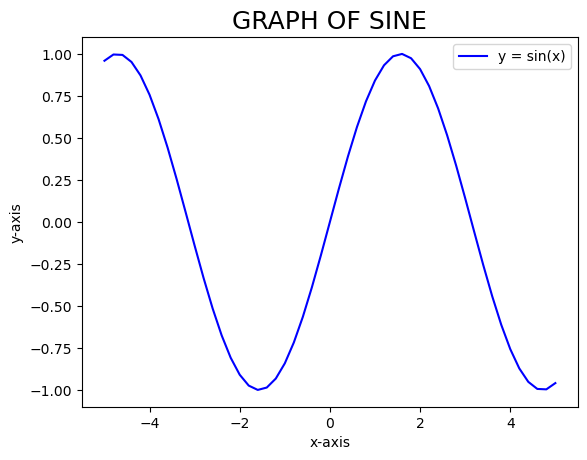

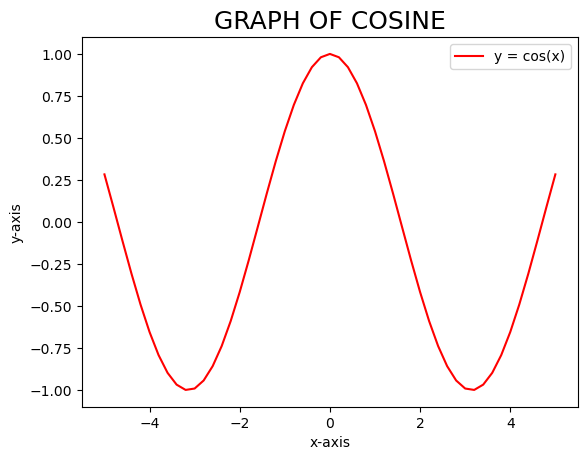

In [86]:
plt.plot(x, y_sin, color = "blue", label = "y = sin(x)")

plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.title("Graph of Sine".upper(), fontsize = 18)
plt.legend()

plt.figure() # separate graphs
plt.plot(x, y_cos, color = "red", label = "y = cos(x)")

plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.title("Graph of Cosine".upper(), fontsize = 18)
plt.legend()
plt.show()



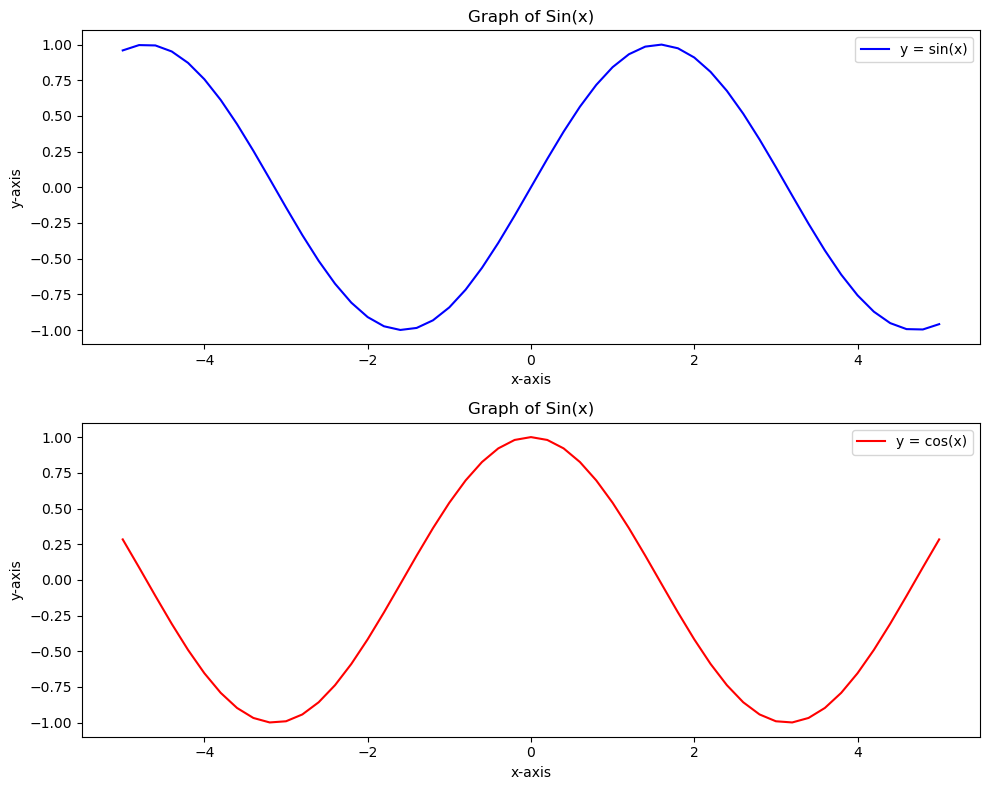

In [114]:
graph, (a1, a2) = plt.subplots(2,1, figsize = (10,8))

a1.plot(x, y_sin, color = "blue", label = "y = sin(x)")
a1.set_title("Graph of Sin(x)")
a1.set_xlabel("x-axis")
a1.set_ylabel("y-axis")
a1.legend()

a2.plot(x, y_cos, color = "red", label = "y = cos(x)")
#a2.plot(x, y_sin, color = "blue", label = "y = sin()")
a2.set_title("Graph of Sin(x)")
a2.set_xlabel("x-axis")
a2.set_ylabel("y-axis")
a2.legend()

plt.tight_layout()
plt.show()

# SymPy - Lab 14

In [117]:
from sympy import symbols, diff, integrate, solve, Eq

In [130]:
x, y = symbols('x y')
print(y)

diff_expr = diff(x**2 + 2, x)
print(diff_expr)

int_expr = integrate(x**2 + 2, x)
print(int_expr)

solution = solve(x**2 - 4, x)
print(f"the solution is {solution}")

eq1 = Eq(3*x + 3*y, 1)
eq2 = Eq(3*x + y, 2)

syst_sol = solve((eq1, eq2), (x,y))

print(syst_sol)


y
2*x
x**3/3 + 2*x
the solution is [-2, 2]
{x: 5/6, y: -1/2}


In [2]:
from sympy import *

In [3]:
x = sqrt(8)

In [7]:
print(N(x))

2.82842712474619


In [17]:
x, y = symbols("x y")
expr = (x**2 - y**2)
print(expr)
print(factor(expr))

x**2 - y**2
(x - y)*(x + y)


In [27]:
print(expr.evalf(subs = {x:1, y:2}))

-3.00000000000000


In [30]:
expr2 = (x**2 - 2*2 - 8)
f = lambdify(x, expr2, "numpy")
arr1 = np.array([1, 2, 3, 4, 5])
print(f(arr1))

[-11  -8  -3   4  13]


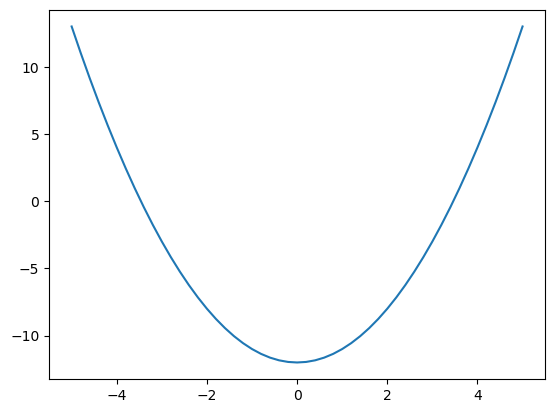

In [33]:
x_axis = np.linspace(-5, 5, 51)
plt.plot(x_axis, f(x_axis))
plt.show()

In [39]:
f2 = lambdify(x, diff(x**2, x)) # one liner for fun
print(f2(3))

6


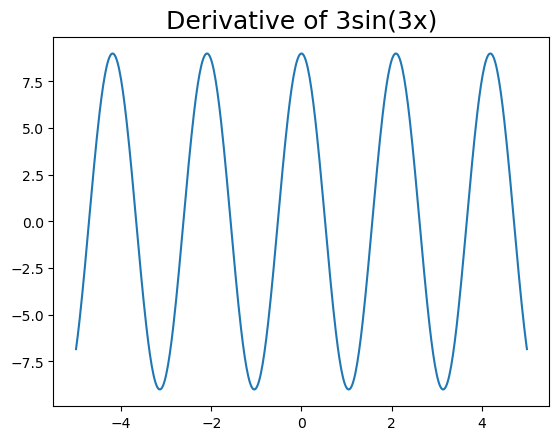

In [51]:
sin_func = lambdify(x,diff(3*sin(3*x)), "numpy")
x_axis = np.linspace(-5, 5, 501)
sin_func
plt.plot(x_axis, sin_func(x_axis))
plt.title("Derivative of 3sin(3x)", fontsize = 18)
plt.show()

# np.loadtxt() vs open()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## pandas

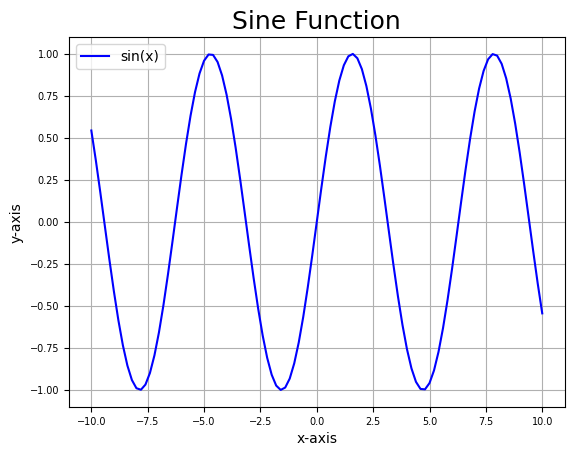

In [37]:
x = np.linspace(-10, 10, 101)
y = np.sin(x)
sin_data = pd.DataFrame({"x": x, "y": y})
#print(sin_data)

sin_data.plot(x = "x", y = "y", title = "Sine Function", xlabel = "x-axis", ylabel = "y-axis", grid = True, legend = True, label = "sin(x)", color = "blue")
plt.legend()
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
plt.title("Sine Function", fontsize = 18)
plt.show()

# plotting

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

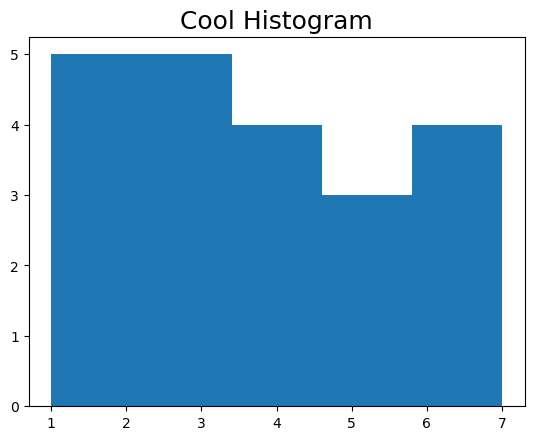

In [62]:
cool_data = pd.DataFrame({"x": [1,2,3,5,2,3,2,5,6,4,3,5,7,4,2,3,4,6,7,4,3]})

cool_hist = plt.hist(cool_data["x"], bins = 5)
plt.title("Cool Histogram", fontsize = 18)
plt.show()

In [69]:
print(max(cool_hist[0])) # gives the largest element in histogram

5.0


# numpy review

In [70]:
import numpy as np

In [73]:
arr1 = np.array([1,2,3,4,2,5], dtype = "int16")
print(arr1)

[1 2 3 4 2 5]
